In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from datetime import timedelta

from IPython.display import display, HTML

import pyarrow as pa

base_folder = "../"

start_time = "2022-10-13"
end_time = "2022-10-14"

workload_name = f"surfsara/{start_time}_{end_time}"

if os.path.exists(f"{base_folder}/resources/traces/{workload_name}"):
    print("Trace folder exists")
else:
    print("ERROR: Trace folder does not exist")
    
if os.path.exists(f"{base_folder}/output/{workload_name}"):
    print("Output folder exists")
else:
    print("ERROR: Output folder does not exist")
    


Trace folder exists
ERROR: Output folder does not exist


## Topologies

In [11]:
def read_topology(topology_name):
    print(f"Topology name: {topology_name}")
    df = pd.read_csv(f"{base_folder}/resources/env/{topology_name}.txt", delimiter=";")
    display(HTML(df.to_html()))
    
def print_topologies():
    topologies = os.listdir(f"{base_folder}/resources/env")
    
    for topology_name in topologies:
        print(f"{topology_name = }")
        df = pd.read_csv(f"{base_folder}/resources/env/{topology_name}", delimiter=";")
        display(HTML(df.to_html()))
        
print_topologies()

topology_name = 'surfsara_200.txt'


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,4464,0.05,27900,279,100,16


topology_name = 'multi.txt'


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,32,3.20,2048,1,256,32
1,B01,B01,48,2.93,1256,6,64,8
2,C01,C01,32,3.20,2048,2,128,16


topology_name = 'surfsara_155.txt'


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,2480,0.00625,15500,155,100,16


topology_name = 'surfsara_279.txt'


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,4464,0.0125,27900,279,100,16


topology_name = 'single.txt'


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,8,3.2,128,1,128,8


## Traces

In [103]:
df_trace = pd.read_parquet(f"{base_folder}/resources/traces/{workload_name}/trace.parquet")
df_trace.head()

Timestamp('2022-10-12 22:00:00')

In [13]:
df_meta =  pd.read_parquet(f"{base_folder}/resources/traces/{workload_name}/meta.parquet")
df_meta.head()

,id,start_time,stop_time,cpu_count,cpu_capacity,mem_capacity
0,2162961,2022-10-12 22:00:00,2022-10-13 02:11:31,16,10000.0,100000
1,2169697,2022-10-12 22:00:00,2022-10-13 22:00:00,16,10000.0,100000
2,2173909,2022-10-12 22:00:00,2022-10-13 22:00:00,16,10000.0,100000
3,2173910,2022-10-12 22:00:00,2022-10-13 22:00:00,16,10000.0,100000
4,2173911,2022-10-12 22:00:00,2022-10-13 22:00:00,16,10000.0,100000


In [38]:
df_energy =  pd.read_parquet(f"{base_folder}/resources/traces/{workload_name}/energy.parquet")
numHosts = len(df_energy.prom_node.unique())
print(numHosts)

df_energy.head()

189


,timestamp,prom_node,surfsara_power_usage,energy
0,2022-10-13 05:05:30+02:00,r27n18,44.0,1320.0
1,2022-10-13 05:06:30+02:00,r27n18,44.0,1320.0
2,2022-10-13 05:07:00+02:00,r27n18,44.0,1320.0
3,2022-10-13 05:07:30+02:00,r27n18,44.0,1320.0
4,2022-10-13 05:08:00+02:00,r27n18,44.0,1320.0


In [40]:
def create_topology(numHosts):
    speed = 0.05
    coresPerHost = 16
    memoryCapacity = 100
    
    with open(f"{base_folder}/resources/env/surfsara_{numHosts}.txt", "w") as wf:
        wf.write("ClusterID;ClusterName;Cores;Speed;Memory;numberOfHosts;memoryCapacityPerHost;coreCountPerHost\n")
        wf.write(f"A01;A01;{coresPerHost*numHosts};{speed};{numHosts*memoryCapacity};{numHosts};{memoryCapacity};{coresPerHost}")

create_topology(numHosts)

# Lets run this in OpenDC!

## Resulting Files

In [145]:
output_folder = f"{base_folder}/output"
workload = "workload=surfsara"
setup = f"surfsara_{numHosts}_0"

df_host = pd.read_parquet(f"{output_folder}/{workload_name}/{setup}/host.parquet")
df_server = pd.read_parquet(f"{output_folder}/{workload_name}/{setup}/server.parquet")
df_service = pd.read_parquet(f"{output_folder}/{workload_name}/{setup}/service.parquet")

def add_absolute_timestamp(df, start_dt):
    df["absolute_timestamp"] = start_dt + (df["timestamp"] - df["timestamp"].min())

add_absolute_timestamp(df_host, df_meta["start_time"].min())
add_absolute_timestamp(df_server, df_meta["start_time"].min())
add_absolute_timestamp(df_service, df_meta["start_time"].min())

df_host["relative_timestamp"] = df_host["timestamp"]
df_service["relative_timestamp"] = df_service["timestamp"]
df_server["relative_timestamp"] = df_server["timestamp"]

df_trace["relative_timestamp"] = datetime(1970,1,1) + (df_trace["timestamp"] - df_trace["timestamp"].min())
df_meta["relative_start_time"] = datetime(1970,1,1) + (df_meta["start_time"] - df_meta["start_time"].min())
df_meta["relative_stop_time"] = datetime(1970,1,1) + (df_meta["stop_time"] - df_meta["stop_time"].min())
df_energy["relative_timestamp"] = datetime(1970,1,1) + (df_energy["timestamp"] - df_energy["timestamp"].min())

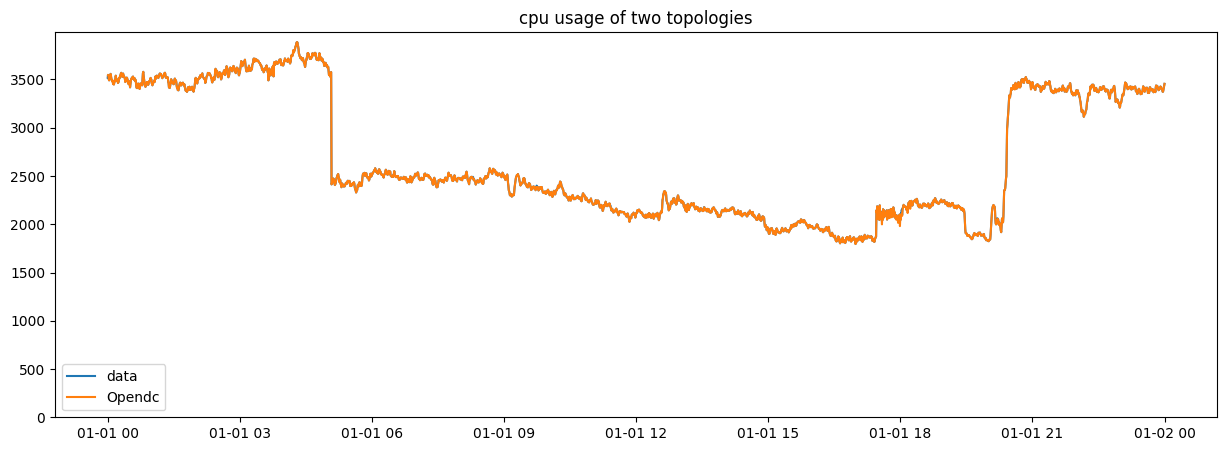

In [159]:
plt.figure(figsize=(15,5))

plt.plot(df_trace.groupby("relative_timestamp").agg({"cpu_usage": "sum"}), label="data")
plt.plot(df_host.groupby("relative_timestamp").agg({"cpu_usage": "sum"}), label="Opendc")

plt.title("cpu usage of two topologies")
plt.legend()
plt.ylim([0, None])

plt.show()

In [160]:
df_trace.groupby("relative_timestamp").agg({"cpu_usage": "sum"})

,cpu_usage
relative_timestamp,
1970-01-01 00:00:00,3518.71
1970-01-01 00:00:30,3545.54
1970-01-01 00:01:00,3542.34
1970-01-01 00:01:30,3500.60
1970-01-01 00:02:00,3490.89
...,...
1970-01-01 23:58:00,3373.98
1970-01-01 23:58:30,3392.62
1970-01-01 23:59:00,3417.04


In [161]:
df_host.groupby("relative_timestamp").agg({"cpu_usage": "sum"})

,cpu_usage
relative_timestamp,
1970-01-01 00:00:30,3545.540014
1970-01-01 00:01:00,3542.340009
1970-01-01 00:01:30,3500.599993
1970-01-01 00:02:00,3490.890027
1970-01-01 00:02:30,3540.550014
...,...
1970-01-01 23:58:00,3373.979971
1970-01-01 23:58:30,3392.619991
1970-01-01 23:59:00,3417.039999


In [162]:
def my_sum(serie):
    idle_power = 1200
    idle_hosts = numHosts - len(serie)
    
    return idle_hosts * idle_power + sum(serie)

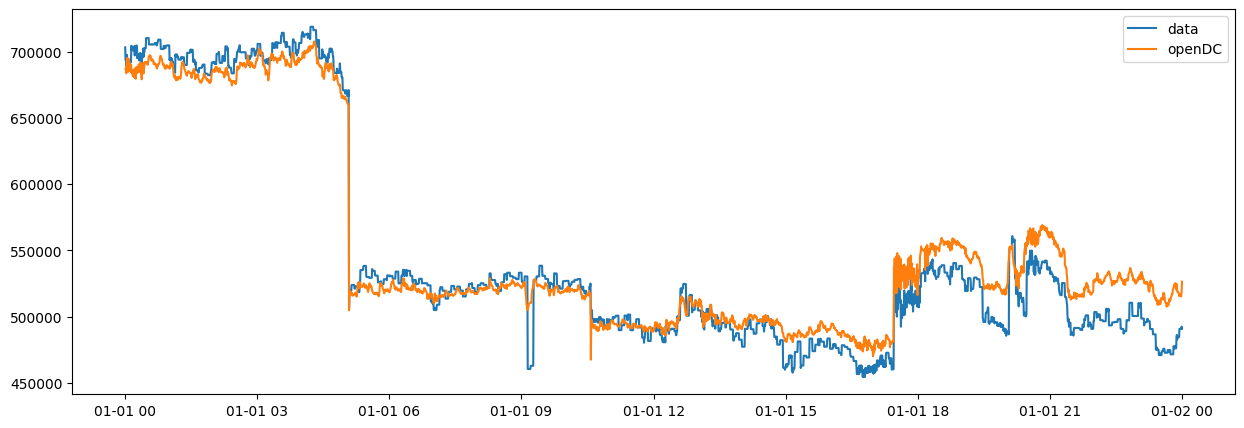

In [235]:
min_power = 40*30
max_power = 280*30

def power_model(utilization):
    power_diff = max_power - min_power
    weighted_utilization = utilization**(1/(5))
    
    return (min_power + (power_diff * weighted_utilization)).real

df_host["energy"] = df_host["cpu_utilization"].apply(power_model).round(2)


plt.figure(figsize=(15,5))
plt.plot(df_energy.groupby("relative_timestamp").agg({"energy": my_sum}), label="data")
plt.plot(df_host.groupby("relative_timestamp").agg({"energy": "sum"}), label="openDC")

plt.legend()
plt.show()

<AxesSubplot: >

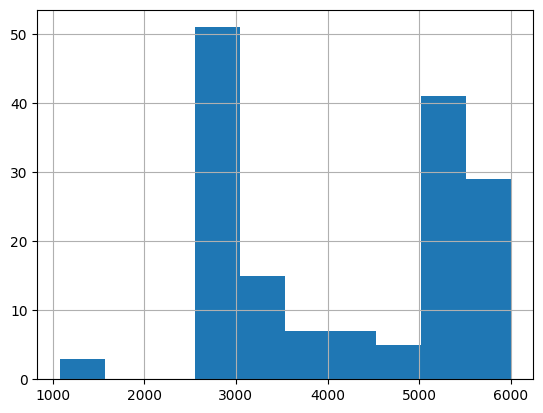

In [197]:
df_energy_timed = df_energy[df_energy.timestamp == "2022-10-13 00:00:30+02:00 	"]

df_energy_timed.energy.hist()

In [193]:
350*30

10500

<AxesSubplot: >

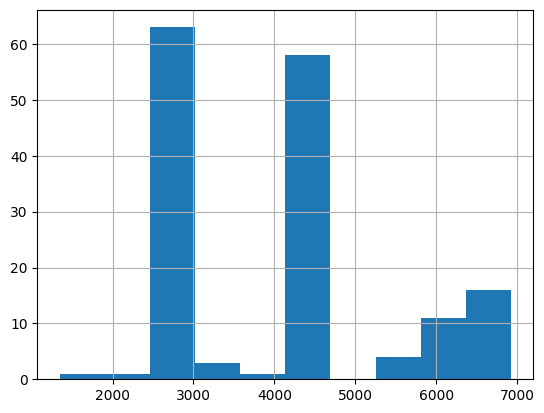

In [196]:
df_host_timed = df_host[df_host.timestamp == df_host.timestamp.min()]

df_host_timed[df_host_timed.guests_running == 1].energy.hist()

In [219]:
def power_model(utilization, min_power, max_power, coefficient):
    power_diff = max_power - min_power
    weighted_utilization = utilization**(coefficient)
    
    return (min_power + (power_diff * weighted_utilization)).real

def mse(data, opendc):
    return ((data - opendc)**2).sum() / len(data) / data.sum()


def calc_fit(min_power, max_power, coefficient):
    df_host["energy"] = df_host["cpu_utilization"].apply(power_model, 
                                                         min_power=min_power, 
                                                         max_power=max_power, 
                                                         coefficient=coefficient).round(2)

    opendc = df_host.groupby("relative_timestamp").agg({"energy": "sum"}).to_numpy().reshape(-1)
    data = df_energy.groupby("relative_timestamp").agg({"energy": my_sum}).to_numpy()[1:].reshape(-1)

    return mse(data, opendc)

In [220]:
min_power = 45*30
max_power = 350*30
coefficient = 1/(3.7)

print(calc_fit(min_power, max_power, coefficient))

0.43875655617851944


In [122]:
sum((data - opendc)**2)/len(data) / data.sum()

0.17329248696672422

In [118]:
(opendc - data).shape

(2880,)

In [204]:
len(df_energy.groupby("relative_timestamp").agg({"energy": my_sum}).to_numpy())

2881